## Section 1: Setup


In [2]:
%pip install ultralytics --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
from ultralytics import YOLO
import shutil

In [4]:
DATA_ROOT = Path("/Users/benediktaaa/Documents/AML/dental-malocclusion/Dataset/omni_coco")  # sesuaikan path aslimu
ANNOTATIONS_DIR = DATA_ROOT / "annotations"
SPLITS = ["train", "val", "test"]

IMAGES_DIRS = {split: DATA_ROOT / split for split in SPLITS}
ANNOTATION_FILES = {split: ANNOTATIONS_DIR / f"instances_{split}.json" for split in SPLITS}

In [5]:
coco_data = {}
for split in SPLITS:
    with open(ANNOTATION_FILES[split], "r") as f:
        coco_data[split] = json.load(f)

for split in SPLITS:
    d = coco_data[split]
    print(f"[{split}] images={len(d['images'])}, annotations={len(d['annotations'])}")

[train] images=2481, annotations=36449
[val] images=857, annotations=12482
[test] images=828, annotations=12207


In [6]:
# drop invalid annotations (bbox di luar image atau ukuran <= 0)

def drop_invalid_annotations(split: str):
    image_id_to_size = {img["id"]: (img["width"], img["height"]) for img in coco_data[split]["images"]}
    valid_anns = []
    for ann in coco_data[split]["annotations"]:
        x, y, w, h = ann["bbox"]
        img_w, img_h = image_id_to_size[ann["image_id"]]
        is_invalid = w <= 0 or h <= 0 or x < 0 or y < 0 or (x + w) > img_w or (y + h) > img_h
        if not is_invalid:
            valid_anns.append(ann)
    coco_data[split]["annotations"] = valid_anns

for split in SPLITS:
    drop_invalid_annotations(split)

In [7]:
# mapping kategori dan helper path 

categories = coco_data["train"]["categories"]
category_id_to_name = {cat["id"]: cat["name"] for cat in categories}
category_name_to_id = {v: k for k, v in category_id_to_name.items()}

def get_image_path(split: str, image_record: dict) -> Path:
    return IMAGES_DIRS[split] / image_record["subfolder1"] / image_record["subfolder2"] / image_record["file_name"]

In [8]:
# index image_id 
def build_image_to_anns_index(split: str):
    index = {}
    for ann in coco_data[split]["annotations"]:
        index.setdefault(ann["image_id"], []).append(ann)
    return index

image_to_anns = {split: build_image_to_anns_index(split) for split in SPLITS}

In [9]:
# device

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Menggunakan device:", device)

Menggunakan device: mps


## Section 2: YOLO

Konversi anotasi COCO -> format YOLO (txt per gambar, normalized xywh),
setup data.yaml, training pakai ultralytics, lalu evaluasi mAP untuk dibandingkan
dengan hasil Faster R-CNN.

YOLO tidak baca COCO JSON langsung. Formatnya:
- 1 file `.txt` per gambar, nama file sama dengan gambarnya (misal `foo.jpg` -> `foo.txt`)
- Tiap baris = satu objek: `class_id x_center y_center width height`
- Semua koordinat dinormalisasi 0-1 (dibagi lebar/tinggi gambar)
- class_id dimulai dari 0 (BEDA dari COCO category_id yang mulai dari 1),
  jadi perlu mapping ulang: category_id 1..10 -> yolo_id 0..9
- Struktur folder yang diharapkan ultralytics:
  dataset_yolo/
    images/{train,val,test}/*.jpg
    labels/{train,val,test}/*.txt

In [10]:
YOLO_ROOT = Path("data/omni_yolo")
YOLO_IMAGES = {split: YOLO_ROOT / "images" / split for split in SPLITS}
YOLO_LABELS = {split: YOLO_ROOT / "labels" / split for split in SPLITS}

for split in SPLITS:
    YOLO_IMAGES[split].mkdir(parents=True, exist_ok=True)
    YOLO_LABELS[split].mkdir(parents=True, exist_ok=True)

print("Folder YOLO dataset siap di:", YOLO_ROOT)

Folder YOLO dataset siap di: data/omni_yolo


In [11]:
# mapping kategori ke yolo id

category_id_to_yolo_id = {cat_id: idx for idx, cat_id in enumerate(sorted(category_id_to_name.keys()))}
yolo_id_to_name = {idx: category_id_to_name[cat_id] for cat_id, idx in category_id_to_yolo_id.items()}

print(category_id_to_yolo_id)
print(yolo_id_to_name)

{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9}
{0: 'HT', 1: 'TT', 2: 'DO', 3: 'IOA', 4: 'TE', 5: 'CFOA', 6: 'TM', 7: 'MR', 8: 'OB', 9: 'FOD'}


In [12]:
# konversi bbox COCO ke format YOLO (x_center, y_center, width, height) relatif terhadap ukuran gambar

def convert_annotations_to_yolo_lines(anns, img_w, img_h):
    lines = []
    for ann in anns:
        x, y, w, h = ann["bbox"]
        yolo_id = category_id_to_yolo_id[ann["category_id"]]

        x_center = (x + w / 2) / img_w
        y_center = (y + h / 2) / img_h
        norm_w = w / img_w
        norm_h = h / img_h

        lines.append(f"{yolo_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}")
    return lines

In [13]:
def build_yolo_dataset(split: str):
    copied, skipped = 0, 0

    for img_record in tqdm(coco_data[split]["images"], desc=f"Convert {split}"):
        src_path = get_image_path(split, img_record)
        if not src_path.exists():
            skipped += 1
            continue

        dst_img_path = YOLO_IMAGES[split] / img_record["file_name"]
        dst_label_path = YOLO_LABELS[split] / (Path(img_record["file_name"]).stem + ".txt")

        # copy gambar (bukan symlink, supaya portable kalau dipindah ke Colab dsb)
        shutil.copy(src_path, dst_img_path)

        anns = image_to_anns[split].get(img_record["id"], [])
        lines = convert_annotations_to_yolo_lines(anns, img_record["width"], img_record["height"])

        with open(dst_label_path, "w") as f:
            f.write("\n".join(lines))

        copied += 1

    print(f"[{split}] copied={copied}, skipped={skipped}")


for split in SPLITS:
    build_yolo_dataset(split)

Convert train:   0%|          | 0/2481 [00:00<?, ?it/s]

[train] copied=2481, skipped=0


Convert val:   0%|          | 0/857 [00:00<?, ?it/s]

[val] copied=857, skipped=0


Convert test:   0%|          | 0/828 [00:00<?, ?it/s]

[test] copied=828, skipped=0


Sengaja copy file gambar (bukan cuma bikin label doang), supaya struktur folder dataset_yolo/ jadi mandiri dan gampang di-zip lalu diupload ke Colab kalau nanti kamu mau training YOLO di sana juga (mengingat pengalaman Faster R-CNN, YOLO mestinya lebih ramah MPS, tapi tetap baik siapkan opsi keduanya).

In [14]:
sample_label_file = list(YOLO_LABELS["train"].glob("*.txt"))[0]
print("File:", sample_label_file)
print(sample_label_file.read_text())

File: data/omni_yolo/labels/train/202139202205255.txt
1 0.480469 0.123167 0.117188 0.146628
0 0.234375 0.866569 0.152344 0.196481
0 0.257812 0.653959 0.132812 0.181818
0 0.267578 0.463343 0.109375 0.152493
0 0.294922 0.329912 0.082031 0.108504
0 0.364258 0.209677 0.115234 0.126100
0 0.606445 0.137830 0.142578 0.140762
0 0.734375 0.190616 0.113281 0.134897
0 0.811523 0.304985 0.087891 0.134897
0 0.863281 0.423754 0.125000 0.173021
0 0.893555 0.596774 0.130859 0.202346
0 0.918945 0.791789 0.119141 0.199413


In [15]:
# buat file data.yaml untuk YOLO

yaml_content = f"""
path: {YOLO_ROOT.resolve()}
train: images/train
val: images/val
test: images/test

names:
"""
for idx in sorted(yolo_id_to_name.keys()):
    yaml_content += f"  {idx}: {yolo_id_to_name[idx]}\n"

yaml_path = YOLO_ROOT / "data.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content.strip())

print(yaml_content)


path: /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/omni_yolo
train: images/train
val: images/val
test: images/test

names:
  0: HT
  1: TT
  2: DO
  3: IOA
  4: TE
  5: CFOA
  6: TM
  7: MR
  8: OB
  9: FOD



## Section 3: Model & Training

In [16]:
model_yolo = YOLO("yolo12n.pt")

In [17]:
results = model_yolo.train(
    data=str(yaml_path),
    epochs=40,            # dinaikkan dari 10 -> siapkan backbone yang lebih matang buat transfer learning ke task IOTN (03_yolo_rf_grade.ipynb)
    imgsz=800,             # lebih kecil dari 1333 Faster R-CNN, YOLO umumnya cukup dengan resolusi lebih rendah
    batch=8,                # coba lebih besar dulu, YOLO lebih ringan dari Faster R-CNN
    device=device,           # otomatis pakai mps/cuda/cpu sesuai yang sudah dideteksi Section 3
    patience=15,             # early stopping kalau val tidak membaik 15 epoch berturut-turut
    project="omni_yolo_runs",
    name="omni_40ep",         # nama run baru, biar checkpoint 10-epoch lama tetap ada & tidak ketiban
)


New https://pypi.org/project/ultralytics/8.4.104 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/omni_yolo/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=omni_

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/40      5.52G      1.459      2.391      1.213         59        800: 100% ━━━━━━━━━━━━ 311/311 1.4it/s 3:380.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 2.2it/s 24.4s0.4ss
                   all        857      12480       0.42      0.345      0.266      0.149

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/40      4.37G      1.389      1.251      1.172        192        800: 0% ──────────── 0/311  1.5s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/40      5.47G      1.389      1.338      1.191         29        800: 100% ━━━━━━━━━━━━ 311/311 1.3it/s 3:510.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 2.5it/s 21.4s0.4ss
                   all        857      12480      0.545      0.431      0.382       0.21

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/40      4.38G      1.261      1.189      1.137        223        800: 0% ──────────── 0/311  0.8s

...

      38/40      4.47G      1.124     0.5494      1.105         13        800: 100% ━━━━━━━━━━━━ 311/311 1.6it/s 3:090.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 2.6it/s 21.1s0.4ss
                   all        857      12480      0.669      0.685      0.676        0.4

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      39/40      4.45G      1.275     0.5709      1.146        136        800: 0% ──────────── 0/311  0.8s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      39/40      4.57G       1.12     0.5403      1.105          6        800: 100% ━━━━━━━━━━━━ 311/311 1.6it/s 3:120.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 2.6it/s 21.1s0.4ss
                   all        857      12480      0.667      0.701      0.679      0.403

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      40/40      4.45G      1.199     0.5881      1.136        108        800: 0% ──────────── 0/311  0.8s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      40/40      4.57G      1.111     0.5355      1.102         19        800: 100% ━━━━━━━━━━━━ 311/311 1.6it/s 3:120.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 2.6it/s 20.9s0.4ss
                   all        857      12480      0.652      0.703      0.674        0.4

40 epochs completed in 2.416 hours.
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/omni_yolo_runs/omni_40ep/weights/last.pt, 5.5MB
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/omni_yolo_runs/omni_40ep/weights/best.pt, 5.5MB

Validating /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/omni_yolo_runs/omni_40ep/weights/best.pt...
Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 MPS (Apple M2)
YOLOv12n summary (fused): 159 layers, 2,558,678 parameters, 0 gradients, 6.3 GFLOPs
                 Class     Images

## Section 4: Evaluasi

In [22]:
metrics = model_yolo.val(data=str(yaml_path), split="test")

print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50   : {metrics.box.map50:.4f}")
print(f"mAP75   : {metrics.box.map75:.4f}")


Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 CPU (Apple M2)
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 48.5±27.4 MB/s, size: 23.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/omni_yolo/labels/test.cache... 828 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 828/828 385.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 3.8s/it 3:194.0ss
                   all        828      12207      0.706      0.722       0.72      0.428
                    HT        716       7638      0.843      0.865        0.9      0.558
                    TT        335        660      0.465      0.453      0.464      0.282
                    DO         39        196      0.627       0.52      0.574      0.346
              

In [26]:
# breakdown mAP per kelas
for idx, ap in enumerate(metrics.box.maps):
    print(f"{yolo_id_to_name.get(idx, 'unknown')}: {ap * 100:.2f}")

HT: 55.75
TT: 28.18
DO: 34.63
IOA: 44.56
TE: 22.11
CFOA: 48.43
TM: 29.65
MR: 59.54
OB: 48.00
FOD: 57.42


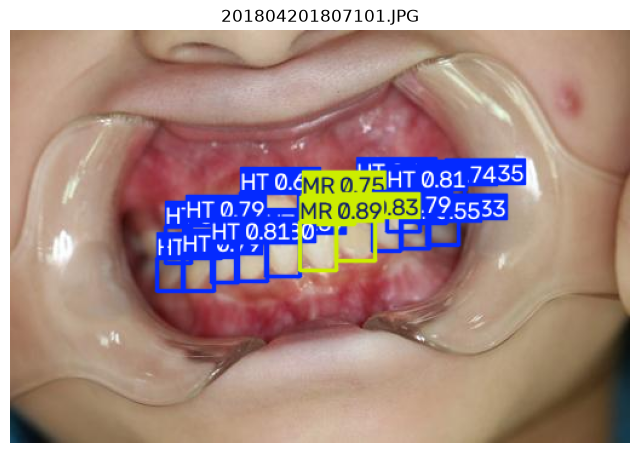

In [27]:
# visualisasi beberapa prediksi di test set

import io
from IPython.display import Image as IPyImage, display

# file gambar OMNI ekstensinya .JPG (uppercase) — glob("*.jpg") case-sensitive di macOS/POSIX
# (beda dari Windows), jadi nggak match dan listnya kosong. Filter manual biar nggak peduli case.
sample_test_image = sorted(p for p in YOLO_IMAGES["test"].iterdir() if p.suffix.lower() == ".jpg")[0]
result = model_yolo.predict(source=str(sample_test_image), conf=0.3)

# result[0].show() buka window viewer sistem terpisah, sering nggak muncul di Jupyter/VS Code.
# plt.show()/display(fig) juga nggak reliable di sini (backend matplotlib ke-ubah "Agg" oleh
# ultralytics, dan integrasi inline IPython buat Figure kadang nggak aktif) — jadi render manual
# ke buffer PNG lewat fig.savefig(), ini jalan di backend apa pun.
plotted = result[0].plot()  # numpy array BGR dengan box+label sudah digambar
fig = plt.figure(figsize=(8, 6))
plt.imshow(plotted[:, :, ::-1])  # BGR -> RGB
plt.axis("off")
plt.title(sample_test_image.name)

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPyImage(data=buf.getvalue()))


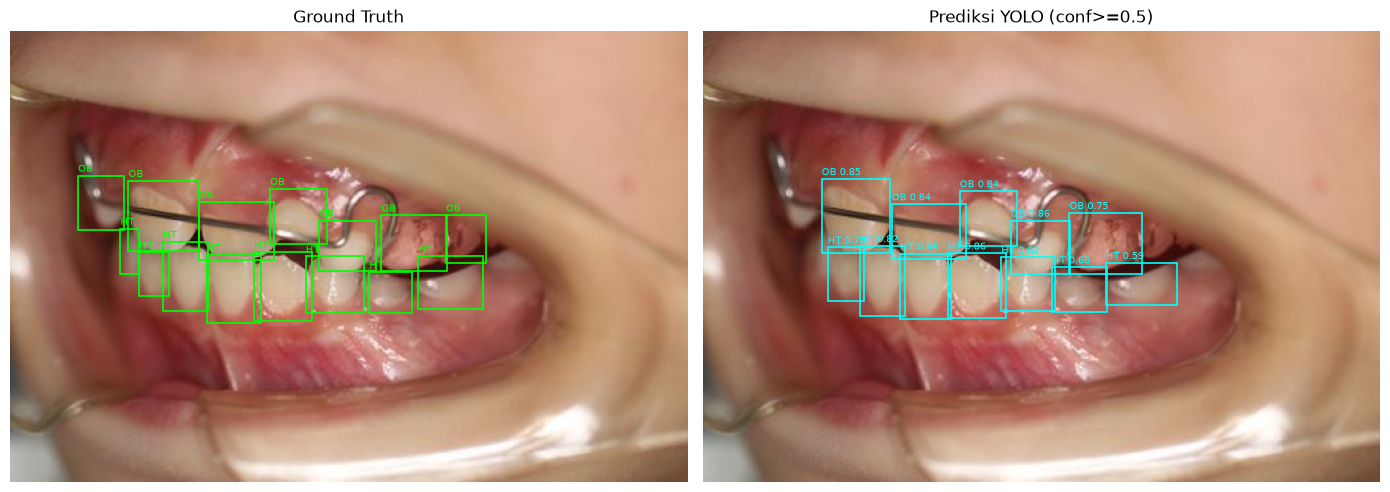

In [29]:
# visualisasi prediksi vs ground truth untuk sample tertentu

import io
import matplotlib.patches as patches
from IPython.display import Image as IPyImage, display


def show_prediction_vs_gt(split, idx, model, score_threshold=0.5):
    img_record = coco_data[split]["images"][idx]
    img_path = YOLO_IMAGES[split] / img_record["file_name"]
    img = Image.open(img_path)

    gt_anns = image_to_anns[split].get(img_record["id"], [])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ground truth (bbox COCO [x,y,w,h] dalam skala piksel asli, gambar belum di-resize)
    axes[0].imshow(img)
    for ann in gt_anns:
        x, y, w, h = ann["bbox"]
        rect = patches.Rectangle((x, y), w, h, linewidth=1.2, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x, y - 3, category_id_to_name[ann["category_id"]], color="lime", fontsize=7)
    axes[0].set_title("Ground Truth")
    axes[0].axis("off")

    # prediksi — ultralytics balikin box "xyxy" langsung dalam skala piksel gambar asli
    result = model.predict(source=str(img_path), conf=score_threshold, verbose=False)[0]
    axes[1].imshow(img)
    for box in result.boxes:
        x_min, y_min, x_max, y_max = box.xyxy[0].tolist()
        cls_id = int(box.cls[0].item())
        score = box.conf[0].item()
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=1.2, edgecolor="cyan", facecolor="none")
        axes[1].add_patch(rect)
        axes[1].text(x_min, y_min - 3, f"{yolo_id_to_name.get(cls_id, '?')} {score:.2f}", color="cyan", fontsize=7)
    axes[1].set_title(f"Prediksi YOLO (conf>={score_threshold})")
    axes[1].axis("off")

    plt.tight_layout()

    # plt.show()/display(fig) nggak reliable di sini (backend matplotlib ke-ubah "Agg" oleh
    # ultralytics, dan integrasi inline IPython buat Figure kadang nggak aktif) — render manual
    # ke buffer PNG lewat fig.savefig(), ini jalan di backend apa pun.
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    display(IPyImage(data=buf.getvalue()))


show_prediction_vs_gt("test", 11, model_yolo)

